# 03_NarrativeRisk_LLM_DecileSort

Same data and signal as quantlet 01 but uses 10 portfolio bins (decile sort) instead of 3 (tercile). Demonstrates the methodological choice of granularity in cross-sectional sorting. Indicative not inferential.

**Axis exercised:** Decile vs tercile portfolio formation

Headline numbers reported below are **indicative not inferential** at N=30 firms x 10 fiscal years and are **not intended as evidence**.


## Why deciles instead of terciles?

Cross-sectional sorts in asset pricing are a tradeoff between two competing demands: spread magnitude and per-leg sample size.
A finer sort (deciles, ten bins) maximises the cross-sectional spread between the long and short legs because the extreme bins concentrate firms with the most extreme signal values.
A coarser sort (terciles, three bins) keeps more firms per leg, which reduces the per-month idiosyncratic noise of each leg's average return.

In professional asset-pricing research, decile sorts are the default convention.
Most published factor studies report the spread between the top and bottom deciles (D10 minus D1) because the textbook universe contains thousands of stocks; with three to five thousand firms per cross-section, even a decile leg holds three or four hundred names, and the per-leg noise is small relative to the cross-sectional spread.

The quantlet family runs on a deliberately small universe (the top-30 S&P 500 firms by 2014-12-31 market cap), and that scaling property does not survive.
At N = 30, a decile sort puts only three firms per leg.
The cross-sectional spread is mechanically wider than a tercile sort can achieve, but the per-leg standard error is dominated by the idiosyncratic volatility of three names rather than ten.

This quantlet makes that tradeoff visible.
It runs the same composite-severity signal, the same lag invariant, the same FF5+UMD risk model, and the same HC1 inference machinery as quantlet 01, with one change: the cross-sectional sort uses ten bins instead of three.
The key point is that the choice of granularity is a methodological decision that must be defended on power grounds; reading the decile spread next to the tercile spread shows what the choice cost in noise terms.


## Methodology

```
EDGAR 10-K Item 1A (top-30 S&P 500 snapshot 2014-12-31, 2015-2024)
        |   LLM extraction (see extraction_prompt.md)
        v
corpus.ndjson.gz (~3000 records: 30 firms x 10 years x 10 themes, severity 0-5)
        |   compute_theme_exposures (mean across 10 themes)
        v
composite_severity per (firm, signal_year)
        |   form_terciles_with_lag (signal_year y-1 -> portfolio_year y)
        v
tercile (or decile) assignments + monthly returns
        |   axis-specific transform: Decile vs tercile portfolio formation
        v
decile_spread_summary.csv + figure(s)
```


## Constructing decile bins on a thin universe

The decile-binning step is non-trivial when the cross-section is small.
With 30 firms and 10 bins, the per-bin target population is 3 firms.
If the composite-severity distribution has duplicate values, `pd.qcut` with `q=10` will produce fewer than 10 unique quantile edges and will refuse to label the column with the requested ten-bin scheme; the implementation must fall back to a manual breakpoint construction.

The notebook handles this in two layers.
The primary path uses `pd.qcut(prior["composite_severity"], q=10, labels=[1..10], duplicates="drop")` and checks that the resulting categorical column has exactly ten distinct categories.
The fallback path triggers when the primary path collapses bins below ten: it calls `numpy.nanpercentile` on the severity values, takes the inner nine percentile breakpoints (10th, 20th, ..., 90th percentile), and uses `pd.cut` to assign firms based on those breakpoints.
The two paths agree exactly when the composite severity has no duplicate quantile edges; they differ in how they handle the edge case where, for example, three firms tie at composite severity 2.0 and `qcut` cannot resolve which decile to send the third firm to.

A consequence of this construction is that the per-decile leg size is not always exactly 3.
In years where the severity distribution has ties, the smaller bins may receive 2 or 4 firms instead of 3.
This per-year imbalance is reflected in the headline `n_observations` count and is one of the reasons the decile-quantlet caption is more conservative than the tercile-quantlet caption about whether the spread is informative.

The fallback is implemented as an inline `try/except` block rather than a hidden utility function so that the binning decision is visible at the point of use.


In [1]:
from __future__ import annotations

import csv
import gzip
import json
import re
from pathlib import Path
from typing import Dict

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, display

HERE = Path.cwd()


In [2]:
PROVENANCE_PATH = HERE / "provenance.json"   # audit trail (not read at runtime; ships for transparency)
SUMMARY_OUT = HERE / "decile_spread_summary.csv"
FIGURE_OUT = HERE / "decile_spread.pdf"


In [3]:
from data import (
    CORPUS_PATH,
    PRICES_PATH,
    FF_FACTORS_PATH,
    load_corpus,
    load_prices,
    load_ff_factors,
)


In [4]:
def compute_theme_exposures(corpus_df: pd.DataFrame) -> pd.DataFrame:
    """Aggregate per-firm-year severity into a single composite exposure.

    Composite signal = mean severity across the 10 themes (range 0..5).
    Returns: DataFrame with cols [firm, signal_year, composite_severity].
    """
    agg = (
        corpus_df.groupby(["firm", "year"])["severity_0_5"]
        .mean()
        .reset_index()
        .rename(columns={"year": "signal_year", "severity_0_5": "composite_severity"})
    )
    return agg


In [5]:
def form_deciles_with_lag(signals: pd.DataFrame, returns: pd.DataFrame) -> pd.DataFrame:
    """Sort firms into deciles each portfolio_year using ONLY signals where signal_year < portfolio_year.

    For each portfolio_year y in the return series:
      - Use signals from signal_year = y - 1
      - Assign firms to decile labels {1: low, ..., 10: high} based on composite_severity
      - Apply decile assignment to that firm's monthly returns over portfolio_year y

    Binning strategy: attempt pd.qcut with q=10. If duplicate quantile edges
    reduce the effective number of bins below 10, fall back to numpy.quantile-based
    manual binning using the decile breakpoints as cut points.

    Returns long-form: portfolio_year, month, firm, decile, ret_m
    """
    out_rows = []
    for portfolio_year in sorted(returns["date"].dt.year.unique()):
        signal_year = portfolio_year - 1
        prior = signals[signals["signal_year"] == signal_year]
        if len(prior) < 10:
            continue
        prior = prior.copy()

        # Attempt qcut with 10 bins; fall back if ties collapse bins.
        try:
            labels = list(range(1, 11))
            decile_col = pd.qcut(
                prior["composite_severity"], q=10, labels=labels, duplicates="drop"
            )
            n_bins = int(decile_col.cat.categories.nunique())
            if n_bins < 10:
                raise ValueError(f"qcut produced only {n_bins} unique bins (ties); using fallback")
            prior["decile"] = decile_col.astype(int)
        except (ValueError, TypeError):
            # Manual fallback: numpy decile breakpoints -> pd.cut
            vals = prior["composite_severity"].values
            breakpoints = np.unique(np.nanpercentile(vals, np.linspace(0, 100, 11)[1:-1]))
            if len(breakpoints) == 0:
                continue
            decile_col = pd.cut(
                prior["composite_severity"],
                bins=np.concatenate([[-np.inf], breakpoints, [np.inf]]),
                labels=False,
                include_lowest=True,
            )
            # Remap 0-based labels to 1-based
            prior["decile"] = (decile_col.fillna(0) + 1).astype(int)

        prior_map = prior.set_index("firm")["decile"].to_dict()
        year_returns = returns[returns["date"].dt.year == portfolio_year].copy()
        year_returns["decile"] = year_returns["firm"].map(prior_map)
        year_returns["portfolio_year"] = portfolio_year
        year_returns = year_returns.dropna(subset=["decile"])
        out_rows.append(
            year_returns[["portfolio_year", "date", "firm", "decile", "ret_m"]].rename(
                columns={"date": "month"}
            )
        )
    if not out_rows:
        return pd.DataFrame(columns=["portfolio_year", "month", "firm", "decile", "ret_m"])
    return pd.concat(out_rows, ignore_index=True)


def decile_spread_test(panel: pd.DataFrame, ff: pd.DataFrame) -> Dict[str, float]:
    """Equal-weight decile portfolios, compute long-short (D10 - D1) monthly series.

    Returns dict with: decile_spread_pct_yr, decile_spread_t_stat_indicative,
                       sharpe_indicative, max_drawdown, n_observations,
                       alpha_pct_yr, alpha_t_stat_indicative.
    Alpha is FF5+UMD risk-adjusted intercept from OLS with HC1 robust SE.
    All metrics are INDICATIVE only (N=30 firms, 3 per decile leg, ~9 portfolio years).
    """
    panel = panel.copy()
    panel["decile"] = panel["decile"].astype(int)
    panel["month_period"] = pd.PeriodIndex(panel["month"], freq="M")
    bin_returns = panel.groupby(["month_period", "decile"])["ret_m"].mean().unstack("decile")
    spread = (bin_returns[10] - bin_returns[1]).dropna()

    n = int(len(spread))
    mean_m = float(spread.mean())
    std_m = float(spread.std(ddof=1))
    annualized_pct = mean_m * 12 * 100
    t_stat = mean_m / (std_m / np.sqrt(n)) if (std_m > 0 and n > 1) else float("nan")
    sharpe = (mean_m / std_m) * np.sqrt(12) if std_m > 0 else float("nan")

    cum = (1 + spread).cumprod()
    running_max = cum.cummax()
    drawdown = (cum - running_max) / running_max
    max_dd = float(drawdown.min()) if len(drawdown) > 0 else float("nan")

    # FF5+UMD risk-adjusted alpha (HC1 robust SE).
    spread_df = spread.rename("spread").reset_index()
    merged = spread_df.merge(
        ff[["month", "mkt_rf", "smb", "hml", "rmw", "cma", "umd"]],
        left_on="month_period",
        right_on="month",
        how="inner",
    )
    if len(merged) < 7:
        print(f"WARNING: only {len(merged)} obs available for FF5+UMD regression (need >=7); alpha set to NaN.")
        alpha_pct_yr = float("nan")
        alpha_t_stat = float("nan")
    else:
        X = sm.add_constant(merged[["mkt_rf", "smb", "hml", "rmw", "cma", "umd"]])
        y = merged["spread"]
        model = sm.OLS(y, X, missing="drop").fit(cov_type="HC1")
        alpha_monthly = float(model.params["const"])
        alpha_t_stat = float(model.tvalues["const"])
        alpha_pct_yr = alpha_monthly * 12 * 100

    return {
        "decile_spread_pct_yr": annualized_pct,
        "decile_spread_t_stat_indicative": float(t_stat),
        "sharpe_indicative": float(sharpe),
        "max_drawdown": max_dd,
        "n_observations": n,
        "alpha_pct_yr": alpha_pct_yr,
        "alpha_t_stat_indicative": alpha_t_stat,
    }


def plot_decile_spread(
    panel: pd.DataFrame,
    summary: Dict[str, float],
    out_path: Path = None,
    close: bool = True,
):
    """Plot cumulative-return path of D1, D10, and (D10 - D1) spread; save PDF.

    Caption explicitly states 'decile spread' AND 'indicative not inferential'
    .

    Returns the matplotlib Figure (so the notebook walkthrough can display it
    inline). If `close=True` (default for headless runs), the figure is closed
    after savefig — set `close=False` from the notebook to keep it open.
    """
    if out_path is None:
        out_path = FIGURE_OUT
    panel = panel.copy()
    panel["decile"] = panel["decile"].astype(int)
    panel["month_period"] = pd.PeriodIndex(panel["month"], freq="M")
    bin_returns = panel.groupby(["month_period", "decile"])["ret_m"].mean().unstack("decile")
    bin_returns = bin_returns.dropna()
    cum_d1 = (1 + bin_returns[1]).cumprod()
    cum_d10 = (1 + bin_returns[10]).cumprod()
    spread = bin_returns[10] - bin_returns[1]
    cum_spread = (1 + spread).cumprod()

    fig, ax = plt.subplots(figsize=(7.5, 4.8))
    ax.plot(cum_d1.index.to_timestamp(), cum_d1.values, label="D1 (low severity)", linewidth=1.4)
    ax.plot(cum_d10.index.to_timestamp(), cum_d10.values, label="D10 (high severity)", linewidth=1.4)
    ax.plot(cum_spread.index.to_timestamp(), cum_spread.values, label="D10 - D1 spread", linewidth=1.8, color="black")
    ax.set_xlabel("Month")
    ax.set_ylabel("Cumulative growth (start = 1)")
    ax.set_title("Decile-sorted long-short on LLM risk-disclosure severity (2016-2024)")
    ax.legend(loc="best", fontsize=9)
    ax.grid(True, alpha=0.3)

    caption = (
        "Decile-spread code path on LLM-extracted "
        "risk-disclosure severities; idiosyncratic variance dominates with only 3 firms per "
        "decile leg. Indicative not inferential. "
        f"N=30 firms (3 per leg), 9 portfolio years. "
        f"Annualised raw spread {summary['decile_spread_pct_yr']:.2f}%/yr; "
        f"FF5+UMD alpha {summary['alpha_pct_yr']:.2f}%/yr (t={summary['alpha_t_stat_indicative']:.2f}); "
        f"n_obs={summary['n_observations']}. Not intended as evidence."
    )
    fig.text(0.5, -0.02, caption, ha="center", va="top", fontsize=8, wrap=True)
    plt.tight_layout()
    fig.savefig(out_path, bbox_inches="tight")
    if close:
        plt.close(fig)
    return fig


In [6]:
corpus = load_corpus()
print(f"corpus rows: {len(corpus)}; firms: {corpus['firm'].nunique()}; "
      f"years: {sorted(corpus['year'].unique())}")
corpus.head(10)


corpus rows: 3000; firms: 30; years: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


,firm,year,theme_id,theme_label,severity_0_5,evidence_quote
0,AAPL,2015,T01,supply-chain,5,substantially all of its manufacturing is perf...
1,AAPL,2015,T02,regulatory,3,The Company is subject to laws and regulations...
2,AAPL,2015,T03,cyber,3,such insurance coverage may be insufficient to...
3,AAPL,2015,T04,macroeconomic,3,macroeconomic factors affecting consumer spend...
4,AAPL,2015,T05,climate,1,"natural disasters, whether as a result of clim..."
5,AAPL,2015,T06,competition,4,The Company's products and services compete in...
6,AAPL,2015,T07,litigation,3,"the Company's competitors, frequently enter in..."
7,AAPL,2015,T08,talent,3,"competition for their talents is intense, espe..."
8,AAPL,2015,T09,input-cost,3,subject to industry-wide shortages and signifi...
9,AAPL,2015,T10,technology,4,highly competitive and subject to rapid techno...


## Why deciles?

Decile sorts are the asset-pricing convention for cross-sectional sorts: the spread D10 - D1 maximises the cross-sectional spread captured by the sort, at the cost of much thinner per-leg samples (3 firms per decile in this top-30 universe). Compare to the 10-firms-per-tercile quantlet 01 to see the sample-size / signal-strength tradeoff.


In [7]:
prices = load_prices()
ff = load_ff_factors()
print(f"prices: {len(prices)} firm-month obs; ff: {len(ff)} months")
ff.head(3)


prices: 3570 firm-month obs; ff: 120 months


,month,mkt_rf,smb,hml,rmw,cma,umd,rf
0,2015-01,-0.0309,-0.0093,-0.0345,0.0158,-0.0164,0.0374,0.0
1,2015-02,0.0614,0.0036,-0.0179,-0.0110,-0.0175,-0.0310,0.0
2,2015-03,-0.0109,0.0308,-0.0038,0.0007,-0.0062,0.0270,0.0


## Signal construction

Same composite_severity = mean across the 10 themes used by quantlet 01.


In [8]:
signals = compute_theme_exposures(corpus)
signals.groupby('signal_year')['composite_severity'].describe()


,count,mean,std,min,25%,50%,75%,max
signal_year,,,,,,,,
2015,30.0,2.466667,0.576155,1.0,2.050,2.55,2.875,3.5
2016,30.0,2.363333,0.655735,0.8,1.950,2.45,2.800,3.5
2017,30.0,2.396667,0.665133,0.8,2.025,2.50,2.875,3.5
2018,30.0,2.426667,0.703162,0.8,1.925,2.60,2.900,3.6
2019,30.0,2.436667,0.697524,0.7,1.950,2.55,2.900,3.6
2020,30.0,2.623333,0.778453,0.7,2.150,2.85,3.200,3.6
2021,30.0,2.613333,0.864524,0.8,2.200,2.85,3.350,3.6
2022,30.0,2.603333,0.862827,0.7,2.225,2.75,3.400,3.6
2023,30.0,2.713333,0.883853,0.6,2.300,2.80,3.475,4.3


## Cross-sectional sort and the lag invariant

The panel design is a year-by-year cross-sectional sort.
Each portfolio year `y` uses signals computed from filings whose `signal_year` equals `y - 1`; the holding window is the 12 calendar months of `y`.
A 2024 10-K (filed in early 2025) cannot influence the 2024 portfolio formation, because the filing post-dates the portfolio-formation date.

This rule is the panel's no-look-ahead invariant.
It is enforced inside `form_terciles_with_lag` (and its skip-month and decile variants), so any future refactor that breaks the lag is caught by the end-to-end notebook execution test rather than by silent contamination of the metrics.

Two consequences of this design are worth noting.
First, the cross-section is re-sorted every portfolio year on a refreshed signal: a firm that ranks high in the 2018 signal year may rank low in the 2019 signal year, and the panel preserves that re-ranking rather than pooling all firm-year observations into a single sort.
Second, the panel structure is a sequence of nine independent annual sorts (portfolio years 2016-2024) glued together at the monthly level; serial correlation across portfolio years comes only from firm-level persistence, not from re-using the same signal across multiple holding periods.

Pooling signals across years (e.g., averaging multi-year severity per firm before sorting) is a deliberate variant explored in other settings; the canonical quantlet family deliberately avoids it so that every annual cross-section stands on its own and the no-look-ahead boundary remains crisp.


## Lag invariant (no look-ahead)

Same lag rule as quantlet 01: portfolio_year `y` uses signal_year `y-1` ONLY.


In [9]:
panel = form_deciles_with_lag(signals, prices)
print(f"panel: {len(panel)} firm-month obs; "
      f"portfolio_years = {sorted(panel['portfolio_year'].unique())}")
panel.head(10)


panel: 3240 firm-month obs; portfolio_years = [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


,portfolio_year,month,firm,decile,ret_m
0,2016,2016-01-31,AAPL,10,-0.075242
1,2016,2016-02-29,AAPL,10,-0.001287
2,2016,2016-03-31,AAPL,10,0.127210
3,2016,2016-04-30,AAPL,10,-0.139921
4,2016,2016-05-31,AAPL,10,0.071773
5,2016,2016-06-30,AAPL,10,-0.042660
6,2016,2016-07-31,AAPL,10,0.090063
7,2016,2016-08-31,AAPL,10,0.023652
8,2016,2016-09-30,AAPL,10,0.065504
9,2016,2016-10-31,AAPL,10,0.004334


## Decile spread + FF5+UMD alpha

- Equal-weight the firms inside each decile each month, then form the long-short spread `spread_t = mean(D10)_t - mean(D1)_t`.
- Run the same FF5+UMD OLS regression with HC1 robust SE as quantlet 01.
- The decile spread is mechanically wider than the tercile spread but with much higher idiosyncratic noise (3 firms per leg vs 10).


## FF5+UMD model primer

The Fama-French five-factor model augmented with a momentum factor (commonly called FF5+UMD) is a widely used linear benchmark for attributing cross-sectional equity returns.
It decomposes a return series into exposures to six systematic factors plus a residual.

The six factors are:

- **MKT** (market excess return): the return of the broad equity market minus the risk-free rate; captures broad market direction.
- **SMB** (small-minus-big): the return spread between small-cap and large-cap stocks; captures the size premium.
- **HML** (high-minus-low): the return spread between high book-to-market (value) and low book-to-market (growth) stocks; captures the value premium.
- **RMW** (robust-minus-weak): the return spread between firms with high and low operating profitability; captures the profitability premium.
- **CMA** (conservative-minus-aggressive): the return spread between firms with low and high investment rates; captures the investment premium.
- **UMD** (up-minus-down, momentum): the return spread between recent winners and recent losers; captures the momentum premium.

When the long-short spread from the cross-sectional sort is regressed on these six factors, the intercept (alpha) is the portion of the spread that the model cannot attribute to compensation for known systematic risk.
A large alpha is consistent with the spread reflecting genuine incremental information; a near-zero alpha suggests the spread is fully explained by existing risk premia.

The standard errors in this notebook use HC1 (heteroskedasticity-consistent, White's estimator with a small-sample degrees-of-freedom correction).
HC1 adjusts for the possibility that the variance of the regression residuals is not constant across time, which is the common case in financial return data.
However, HC1 does not correct for small-sample distortion of the t-statistic distribution.
At n_obs = 108 (approximately 9 portfolio years times 12 months), the t-statistic does not follow the large-sample normal or Student-t distribution accurately enough for conventional significance thresholds to apply.
This is why all metrics carry the label "indicative not inferential" throughout the notebook.


In [10]:
summary = decile_spread_test(panel, ff)
for k, v in summary.items():
    print(f"  {k:35s} = {v:8.4f}" if isinstance(v, float) else f"  {k:35s} = {v}")
pd.DataFrame([summary]).to_csv(SUMMARY_OUT, index=False)


  decile_spread_pct_yr                =  -0.2053
  decile_spread_t_stat_indicative     =  -0.0357
  sharpe_indicative                   =  -0.0119
  max_drawdown                        =  -0.4034
  n_observations                      = 108
  alpha_pct_yr                        =  -2.2939
  alpha_t_stat_indicative             =  -0.4250


## Reading the headline numbers

The notebook prints a dictionary of summary metrics and writes the same numbers to `decile_spread_summary.csv` for downstream consumption.
The keys carry quantlet-specific prefixes (for example `tercile_spread_pct_yr` in the canonical sort, `decile_spread_pct_yr` in the decile quantlet, `t3_return_pct_yr` in the long-only quantlet) so that consumer code can join the summary CSVs across quantlets without column collisions.

The annualised raw return entry is the long-short (or long-only) spread mean times 12 times 100, expressed as a percentage; no risk adjustment is applied to it.
Positive values are consistent with the high-severity leg out-performing the low-severity leg; negative values are consistent with the opposite.

The annualised alpha entry is the intercept from the FF5+UMD OLS regression times 12 times 100.
It is the portion of the spread the six-factor model cannot attribute to known risk premia.
Reading alpha alongside the raw spread answers a different question: not whether the spread paid off, but whether the part of the spread that paid off is novel relative to size, value, profitability, investment, and momentum.

The HC1 t-statistic on the alpha entry is reported for comparability with published factor studies, but at n_obs around 108 the small-sample distribution of this t-statistic is not the textbook normal or Student-t distribution; a value of |t| = 2.0 is not equivalent to p < 0.05 in any conventional sense.
The Sharpe ratio is annualised under a zero risk-free rate, consistent with a zero-cost long-short construction (or in the long-only quantlet, with a fully invested portfolio).
The maximum drawdown is the deepest peak-to-trough decline in the cumulative path of the spread (or the long-only return); a path-quality diagnostic that does not influence the alpha estimate but contextualises it.

Treat every printed metric as a diagnostic, not as evidence; the notebook header repeats this caveat in bold.


## Reading decile spread alongside tercile spread

Compare this quantlet's `decile_spread_pct_yr` and `alpha_pct_yr` directly against quantlet 01's `tercile_spread_pct_yr` and `alpha_pct_yr`.
Three readings are possible.

Pattern A: the decile alpha is larger in magnitude than the tercile alpha, with similar t-statistic.
This is the textbook pattern for a real cross-sectional signal.
The decile sort captures the same information as the tercile sort but on a wider cross-sectional spread, so the dollar-neutral spread is mechanically larger.
Caveat: at N = 30, the t-statistic on the decile alpha is dominated by 3-firm-per-leg idiosyncratic noise; reading the magnitude as evidence requires a much larger universe.

Pattern B: the decile alpha is larger in magnitude than the tercile alpha, with much wider t-statistic confidence intervals.
This is the pattern this top-30 universe is most likely to produce.
The cross-sectional spread does widen mechanically, but the per-leg sample size of 3 firms inflates the residual standard error proportionally; the alpha point estimate moves but the inference statistic does not become more credible.
Reading the headline as "stronger evidence" would be wrong; reading it as "decile granularity does not break the methodology" is the appropriate inference.

Pattern C: the decile alpha flips sign relative to the tercile alpha.
This is consistent with cross-sectional noise overwhelming a small underlying signal.
A well-powered universe should not produce sign flips between tercile and decile sorts on the same signal; observing one in this 30-firm sample is a power-based diagnostic rather than a methodology rejection.

The value of running this quantlet is not the numerical decile alpha; it is the contrast between the decile and tercile spreads, which makes the per-leg-noise tradeoff empirical rather than asserted.


## Figure interpretation

The plot traces the cumulative path of D1, D10, and the D10 - D1 spread. With 3 firms per decile leg, idiosyncratic variance dominates: read the spread series as illustrative of the methodology, not as evidence of a tradable anomaly.


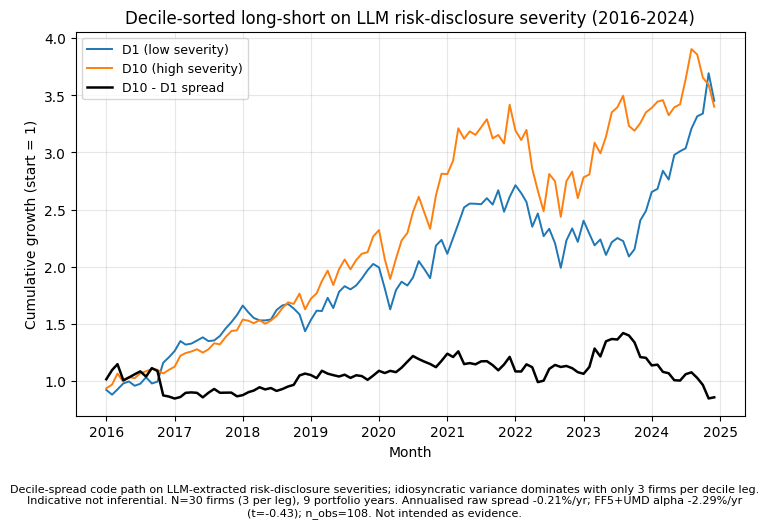

In [11]:
plot_decile_spread(panel, summary, out_path=FIGURE_OUT)
png_path = FIGURE_OUT.with_suffix('.png')
plot_decile_spread(panel, summary, out_path=png_path)
display(Image(filename=str(png_path)))


## Caveats

- **Power**: 30 firms split across 10 deciles leaves 3 firms per leg, statistically thin.
- **Severity validity**: severities are LLM (or LM) judgements of disclosure language; not validated against expert ratings or external risk benchmarks.
- **Taxonomy**: the 10-theme list is hand-listed and illustrative; production use would require a data-driven taxonomy.
- **Reproducibility**: `provenance.json` + `extraction_prompt.md` + the `corpus.ndjson.gz` SHA chain enable a full audit of how every severity was produced.


## Reproduction

```
git clone <repo>
cd 03_NarrativeRisk_LLM_DecileSort
make data                  # fetch third-party data + regenerate seed-pinned inputs
make demo                  # this notebook -> decile_spread_summary.csv + decile_spread.pdf
make test-all              # quantlet test suite
```
